# Random rollout on CartPole

This notebook shows the smallest end-to-end loop: build a **vector** environment from `EnvConfig`, sample random actions, and watch the rollout as an animated GIF.

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import io
import os

os.environ.setdefault("SDL_AUDIODRIVER", "dummy")

from IPython.display import Image, display
from PIL import Image as PILImage

from mouse_envs import EnvConfig, make_vector_env

## Configure the environment

- `num_envs=1` runs one CartPole instance.
- `max_episode_steps` caps episode length.
- `seed` fixes RNG for reproducibility.
- `kwargs` passes `render_mode="rgb_array"` so frames can be captured.

In [2]:
cfg = EnvConfig(
    id="CartPole-v1",
    seed=0,
    num_envs=1,
    max_episode_steps=500,
    kwargs={"render_mode": "rgb_array"},
)
env = make_vector_env(cfg)

## Rollout

Run CartPole for 100 random-action steps. Frames are captured each step and assembled into an animated GIF at the end.

/home/user/Repos/mouse-env/.venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


{'action': {'discrete': tensor(0)}}
{'time': tensor(0), 'observation': {'continuous': tensor([-0.0147,  0.0180,  0.0376, -0.0261])}, 'reward': tensor(0.), 'done': tensor(0), 'episode_index': 0, 'reward_episodic': 0.0}
{'action': {'discrete': tensor(0)}}
{'time': tensor(1), 'observation': {'continuous': tensor([-0.0143, -0.1776,  0.0370,  0.2781])}, 'reward': tensor(1.), 'done': tensor(0), 'episode_index': 0, 'reward_episodic': 0.002}
{'action': {'discrete': tensor(1)}}
{'time': tensor(2), 'observation': {'continuous': tensor([-0.0179,  0.0169,  0.0426, -0.0026])}, 'reward': tensor(1.), 'done': tensor(0), 'episode_index': 0, 'reward_episodic': 0.006}
{'action': {'discrete': tensor(1)}}
{'time': tensor(3), 'observation': {'continuous': tensor([-0.0175,  0.2114,  0.0426, -0.2816])}, 'reward': tensor(1.), 'done': tensor(0), 'episode_index': 0, 'reward_episodic': 0.01}
{'action': {'discrete': tensor(1)}}
{'time': tensor(4), 'observation': {'continuous': tensor([-0.0133,  0.4059,  0.0369, -0

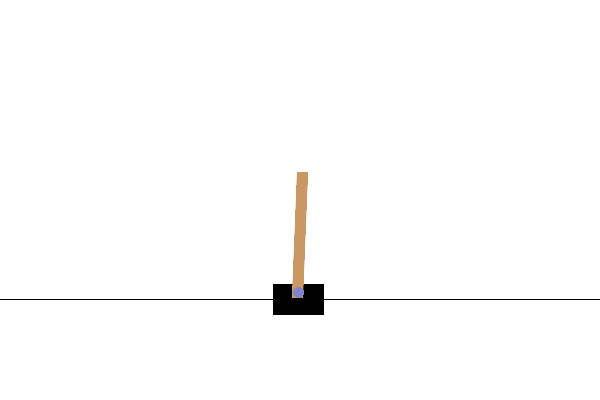

In [3]:
frames = []
for _ in range(200):
    actions = env.sample_random_actions()
    result, metrics = env.step(actions)
    frames.append(PILImage.fromarray(env.render()[0]))
    print(actions[0])
    print(result[0])

video_buffer = io.BytesIO()
frames[0].save(
    video_buffer,
    format="GIF",
    save_all=True,
    append_images=frames[1:],
    duration=50,
    loop=0,
)
display(Image(data=video_buffer.getvalue()))

## Cleanup

In [4]:
env.close()